## Step 1: Import Libraries

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Data

In [10]:
stock_returns = pd.read_csv(
    "../data/stock_returns_log.csv", index_col=0, parse_dates=True
)
stock_meta = pd.read_csv("../data/stock_meta.csv", index_col=0)

print(f"Stock returns: {stock_returns.shape}")
print(f"Stock meta:    {stock_meta.shape}")

Stock returns: (1508, 410)
Stock meta:    (505, 3)


## Step 3: Set Parameters

In [4]:
# Number of eigenportfolios to retain as risk factors
N_FACTORS = 15
# 252 trading days = approximately one calendar year
PCA_WINDOW = 252

## Step 4: Extracting factors with PCA


In [ ]:
def run_pca(
    returns: pd.DataFrame, n_factors: int = N_FACTORS
) -> tuple[np.array, np.array, PCA, StandardScaler]:
    """
    Standardize returns and extract PCA factors.

    Parameters
    ----------
    returns : shape (M, N)
        Raw log returns for N stocks over M days
    n_factors : int
        Number of principal components to extract

    Returns
    -------
    factors : np.array, shape (M, n_factors)
        Return F (F_{ij} is factor i's returns on day j)
    weights : np.array, shape (N, n_factors)
        Return Q (Q_{ij} is factor i's jth stock value)
    pca : fitted PCA object
        Kept so we can transform new data later
    scaler : fitted StandardScaler object
        Kept so we can standardize new data consistently
    """
    # Step 1: Standardize returns
    scaler = StandardScaler()
    raw_returns = returns.values  # Shape (M, N)
    scaled_returns = scaler.fit_transform(raw_returns)  # Shape (M, N)

    # Step 2: Run PCA
    pca = PCA(n_components=n_factors)
    pca.fit(scaled_returns)

    # Step 3: Scale components by volatility (eq. 8)
    returns_std = returns.std(ddof=1).values

    # Step 4: Compute weights for each stock for each eigenvector
    weights = pca.components_.T / returns_std.reshape(-1, 1)  # Shape (N, n_factors)

    # Step 5: Compute Eigenportfolio Returns (eq. 9)
    factors = raw_returns @ weights  # Shape (M, n_factors)

    return factors, weights, pca, scaler


## Step 5: Computing Idiosyncratic Variance

In [7]:
def compute_idiosyncratic_var(pca: PCA) -> int:
    """
    Calculates the idiosyncratic variance (epsilon^2) for each stock.

    Parameters
    ----------
    pca: The fitted sklearn.decomposition.PCA object

    Returns
    -------
    idiosyncratic_var (epsilon squared)
    """

    explained_var = pca.explained_variance_  # shape: (m,)

    components = pca.components_  # shape: (m, N)

    # epsilon^2 = sum(lambda_k * (v_i^(k))^2 ) for each stock i
    total_explained_var = np.sum(explained_var.reshape(-1, 1) * components**2, axis=0)

    idiosyncratic_var = 1 - total_explained_var
    idiosyncratic_var = np.clip(idiosyncratic_var, 0.0, None)

    return idiosyncratic_var

In [130]:
factors, weights, pca, scaler = run_pca(returns=stock_returns.iloc[0:PCA_WINDOW, :])

## Step 6: Visualize Eigenvalues Distribution

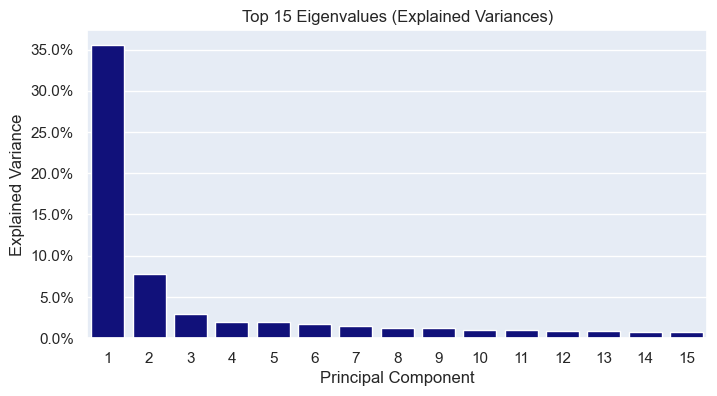

In [ ]:
from matplotlib.ticker import PercentFormatter

var_ratio = pca.explained_variance_ratio_

df = pd.DataFrame(
    {
        "Principal Component": np.arange(1, len(var_ratio) + 1),
        "Explained Variance": var_ratio,
    }
)

sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#e6ecf5"})
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=df, x="Principal Component", y="Explained Variance", color="darkblue"
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Top 15 Eigenvalues (Explained Variances)")

plt.show()

## Step 7: Visualize Weights of First Component (Eigenvector)

Notice the first eigenvector $v_0$ has all positive weights as it measures the overall market's movement. Since subsequent eigenvectors have to be orthogonal to the first, it forces them to have both positive and negatives weights. This is exactly what we take advantage of via mean-reversion.

In [131]:
def graph_weights(factor_num: int):
    weight = weights[:, factor_num]
    df = pd.DataFrame(
        {
            "Ticker": stock_returns.columns,
            "Weight": weight,
        }
    )
    df = df.sort_values(by="Weight", ascending=False).reset_index(drop=True)
    if (df["Weight"] < 0).any():
        zero_idx = df["Weight"].abs().idxmin()
        df = df.iloc[zero_idx - 20 : zero_idx + 20]
    else:
        df = df.tail(40)

    sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#e6ecf5"})
    plt.figure(figsize=(10, 6))
    plt.xticks(rotation=90, fontsize=8)
    colors = ["#2ca02c" if w > 0 else "#d62728" for w in df["Weight"]]

    ax = sns.barplot(
        data=df, x="Ticker", y="Weight", palette=colors, hue="Ticker", legend=False
    )
    plt.title(f"Factor Weights: {factor_num}")
    plt.show()

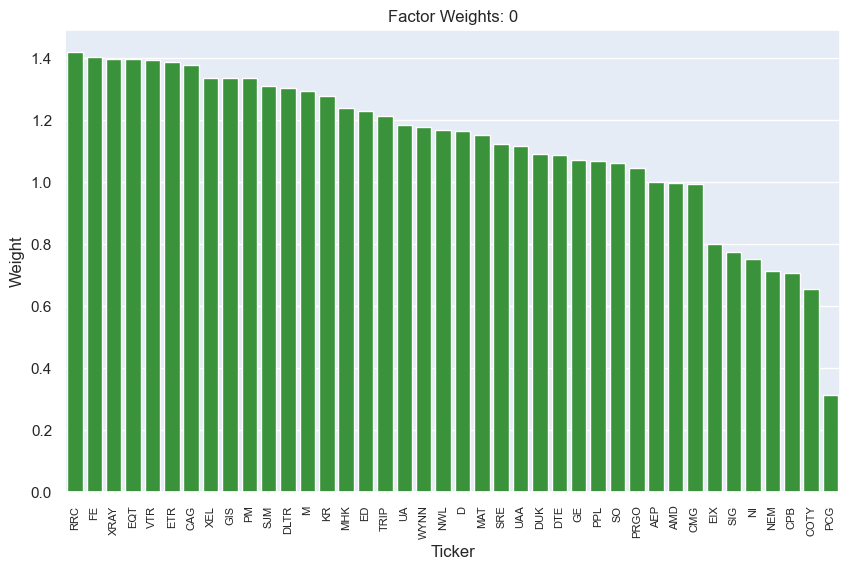

In [132]:
graph_weights(0)

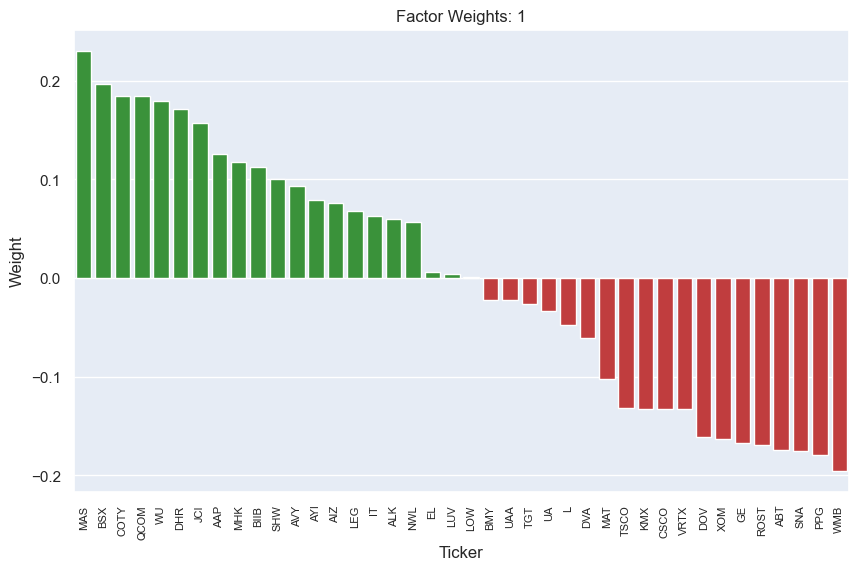

In [133]:
graph_weights(1)

In [136]:
top = df.head(10).reset_index(drop=True)
bottom = df.tail(10).iloc[::-1].reset_index(drop=True)

display(pd.concat([top, bottom], axis=1, keys=["TOP LONGS", "TOP SHORTS"]))

TOP LONGS           TOP SHORTS          
     Ticker    Weight     Ticker    Weight
0      VRSK  0.273663       ORCL -0.276371
1       COO  0.248627         CI -0.270830
2       MAS  0.230708        HUM -0.261888
3       BSX  0.196702        LEN -0.246569
4      COTY  0.185132        RRC -0.236053
5      QCOM  0.184842        CNC -0.234732
6        WU  0.179841        MMM -0.234430
7       DHR  0.171400        TJX -0.217313
8       JCI  0.157194       GILD -0.212762
9       AAP  0.126004        WMB -0.195327

## Step 8: 